# Demo 2 — *Producing* Earth embeddings with MOSAIKS

**ISPRS 2026 Tutorial · Towards Geospatial Embeddings**

In Demo 1 we *used* ready-made embeddings. Now we'll *make our own* — and discover that you don't
need a giant pre-trained model to get a useful embedding. We'll use **MOSAIKS random convolutional
features (RCF)**: a featurizer with **zero training** that nonetheless turns satellite images into
vectors a simple linear model can classify.

Along the way we'll answer two practical questions every embedding-builder faces:
1. **Which spectral bands** should I feed in? (RGB? or all of Sentinel-2's bands?)
2. **What image resolution** do I need?

**Data:** [EuroSAT](https://github.com/phelber/EuroSAT) — 64×64 Sentinel-2 patches, 10 land-cover
classes, 13 spectral bands. We ship a small balanced subset so this runs fast.

> 💡 **Runtime tip:** this notebook runs on a free **CPU** runtime (a few minutes of compute).
> For near-instant results, switch to a GPU: *Runtime → Change runtime type → T4 GPU*.

In [1]:
# === Setup ===
import sys, time, warnings
from pathlib import Path
RUNNING_IN_COLAB = "google.colab" in sys.modules
if RUNNING_IN_COLAB:
    !pip install -q huggingface_hub scikit-learn matplotlib timm

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
warnings.filterwarnings("ignore")   # keep tutorial output tidy

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch device:", DEVICE, "| running in Colab:", RUNNING_IN_COLAB)
if DEVICE == "cpu":
    print("Tip: Runtime -> Change runtime type -> T4 GPU makes the heavy cells ~30x faster.")

# Pre-packaged data lives in a public Hugging Face dataset repo (no login needed).
DATA_REPO = "kklmmr/isprs26-earth-embeddings"   # public HF dataset (no login needed)

def fetch(filename):
    """Local file if present (organizer testing), else download from the Hub."""
    for base in (Path("local/demo2"), Path("../local/demo2")):
        if (base / filename).exists():
            return str(base / filename)
    from huggingface_hub import hf_hub_download
    return hf_hub_download(DATA_REPO, f"demo2/{filename}", repo_type="dataset")

Torch device: cpu | running in Colab: False
Tip: Runtime -> Change runtime type -> T4 GPU makes the heavy cells ~30x faster.


## 1 · Meet the data

Each EuroSAT image is a small Sentinel-2 patch with **13 spectral bands** (not just red/green/blue —
also near-infrared, red-edge and short-wave infrared, which carry a lot of information about
vegetation, water and built-up surfaces). Let's look at one true-colour example per class.

(3000, 64, 64, 13) images | 10 classes | 13 bands
bands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A']


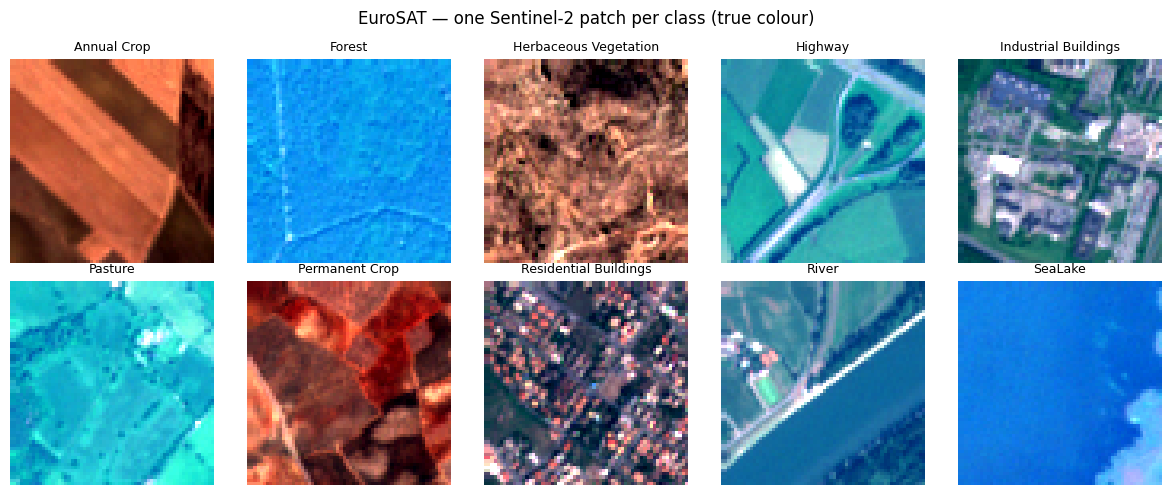

In [2]:
data = np.load(fetch("eurosat_subset_ms.npz"), allow_pickle=True)
images = data["images"]                 # (N, 64, 64, 13) uint16 reflectance
labels = data["labels"]                 # (N,)
class_names = [str(c) for c in data["class_names"]]
band_names  = [str(b) for b in data["band_names"]]   # B01..B12, B8A
rgb_idx     = list(data["rgb_indices"])              # indices of (B04, B03, B02) = true-colour RGB
print(images.shape, "images |", len(class_names), "classes |", images.shape[-1], "bands")
print("bands:", band_names)

def to_rgb(img, p=(2, 98)):
    """True-colour view with a simple percentile contrast stretch."""
    rgb = img[..., rgb_idx].astype(np.float32)
    lo, hi = np.percentile(rgb, p)
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, c in zip(axes.ravel(), range(len(class_names))):
    i = np.where(labels == c)[0][0]
    ax.imshow(to_rgb(images[i])); ax.set_title(class_names[c], fontsize=9); ax.axis("off")
plt.suptitle("EuroSAT — one Sentinel-2 patch per class (true colour)")
plt.tight_layout(); plt.show()

## 2 · The MOSAIKS idea: random convolutional features

How do we turn an image into a vector? MOSAIKS (Rolf et al., 2021) uses a wonderfully simple recipe
— and **nothing is trained**:

1. **Grab random patches.** Cut out a bunch of tiny (3×3) patches from the images themselves. These
   become our convolutional **filters** — little templates for colours/edges/textures.
2. **Slide them over each image** (a convolution). Where a filter matches the local image content,
   it produces a strong response.
3. **Two-sided ReLU.** Keep both strong *positive* and strong *negative* responses (a filter that is
   strongly *anti*-matched is informative too).
4. **Average over the image.** Average each filter's responses across all positions → one number per
   filter. With `K` filters and the two-sided trick, every image becomes a **`2K`-dimensional vector**.

That vector *is* our embedding. Let's implement it in a few lines.

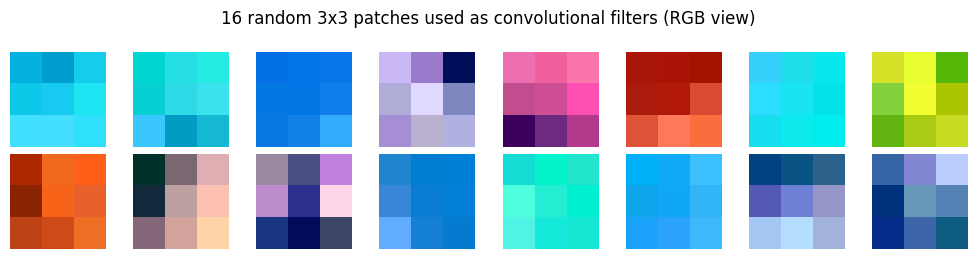

In [3]:
def sample_patches(imgs, num_patches=256, patch_size=3, seed=0):
    """Pick random little image patches to use as fixed convolutional filters."""
    rng = np.random.default_rng(seed)
    n, h, w, c = imgs.shape
    filt = np.empty((num_patches, c, patch_size, patch_size), np.float32)
    for k in range(num_patches):
        i  = rng.integers(n)
        y0 = rng.integers(h - patch_size + 1)
        x0 = rng.integers(w - patch_size + 1)
        p = imgs[i, y0:y0+patch_size, x0:x0+patch_size, :].transpose(2, 0, 1).astype(np.float32)
        p -= p.mean()                          # remove brightness -> respond to pattern, not level
        nrm = np.linalg.norm(p)
        filt[k] = p / nrm if nrm > 1e-6 else p
    return filt

def rcf_features(imgs, filt, bias=1.0, batch=256):
    """Convolve with the random filters, two-sided ReLU, then global-average-pool."""
    x = torch.from_numpy(imgs.transpose(0, 3, 1, 2).astype(np.float32))
    w = torch.from_numpy(filt).to(DEVICE)
    out = []
    with torch.no_grad():
        for s in range(0, len(x), batch):
            b    = x[s:s+batch].to(DEVICE)
            conv = F.conv2d(b, w)                       # (B, K, H', W')
            pos  = F.relu(conv - bias).mean((2, 3))     # strong positive matches
            neg  = F.relu(-conv - bias).mean((2, 3))    # strong negative matches
            out.append(torch.cat([pos, neg], 1).cpu())
    return torch.cat(out).numpy()                       # (N, 2K)

# What do the random filters look like? (true-colour view of 16 of them)
demo_filt = sample_patches(images, num_patches=16, seed=1)
fig, axes = plt.subplots(2, 8, figsize=(10, 2.6))
for ax, f in zip(axes.ravel(), demo_filt):
    rgb = f[rgb_idx].transpose(1, 2, 0)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
    ax.imshow(rgb); ax.axis("off")
plt.suptitle("16 random 3x3 patches used as convolutional filters (RGB view)")
plt.tight_layout(); plt.show()

## 3 · From embeddings to predictions: a linear probe

We now (1) embed every image with RCF, then (2) train a **simple linear classifier**
(logistic regression) on top. The classifier is the *only* thing that learns — and it's linear, so
it's fast. If a plain linear model on our embeddings can tell forests from cities from rivers, the
embedding must be capturing something real.

We first standardise the bands (z-score) so the random filters respond to *pattern*, not brightness.

In [4]:
# Work on a balanced subset for speed. Raise these for higher accuracy (and use a GPU runtime).
N_PER_CLASS, K = 150, 256
rng = np.random.default_rng(0)
sel = np.concatenate([rng.permutation(np.where(labels == c)[0])[:N_PER_CLASS]
                      for c in range(len(class_names))])
X, y = images[sel], labels[sel]
tr, te = train_test_split(np.arange(len(X)), test_size=0.3, stratify=y, random_state=0)
print(f"Working set: {len(X)} images  ({len(tr)} train / {len(te)} test)")

def standardize(train_imgs, *more):
    flat = train_imgs.reshape(-1, train_imgs.shape[-1])
    mu, sd = flat.mean(0), flat.std(0) + 1e-6
    return [((a - mu) / sd).astype(np.float32) for a in (train_imgs,) + more]

def run_probe(imgs, K=K, seed=0):
    """RCF-embed images, fit a linear probe on the train split; return (model, scaler, acc, preds)."""
    Xtr, Xte = standardize(imgs[tr], imgs[te])
    filt = sample_patches(Xtr, K, seed=seed)
    Ftr, Fte = rcf_features(Xtr, filt), rcf_features(Xte, filt)
    scaler = StandardScaler().fit(Ftr)
    clf = LogisticRegression(max_iter=1000).fit(scaler.transform(Ftr), y[tr])
    preds = clf.predict(scaler.transform(Fte))
    return clf, scaler, (preds == y[te]).mean(), preds

t = time.time()
clf, scaler, acc, preds = run_probe(X)
print(f"RCF ({2*K}-dim embedding) + linear probe -> test accuracy = {acc:.1%}"
      f"   [{time.time()-t:.1f}s on {DEVICE}]")

Working set: 1500 images  (1050 train / 450 test)


RCF (512-dim embedding) + linear probe -> test accuracy = 75.3%   [46.7s on cpu]


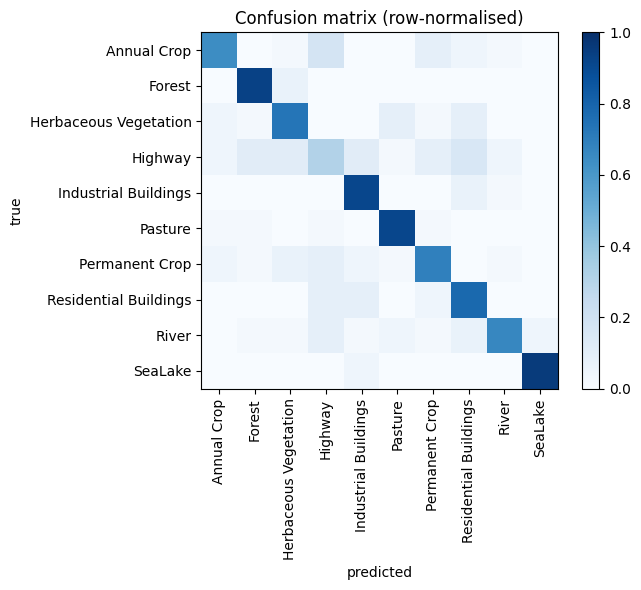

In [5]:
# Where does it succeed / get confused?
cm = confusion_matrix(y[te], preds, normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=90)
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.colorbar(im, fraction=0.046); plt.title("Confusion matrix (row-normalised)")
plt.tight_layout(); plt.show()

## 4 · Experiment 1 — does it matter which spectral bands we use?

Optical satellites see far beyond human vision. Let's compare embeddings built from:
**RGB** (3 bands) → **RGB + near-infrared** (4) → **all 13 Sentinel-2 bands**.

RGB (3)          -> 59.1%


RGB+NIR (4)      -> 72.2%


All bands (13)   -> 75.3%


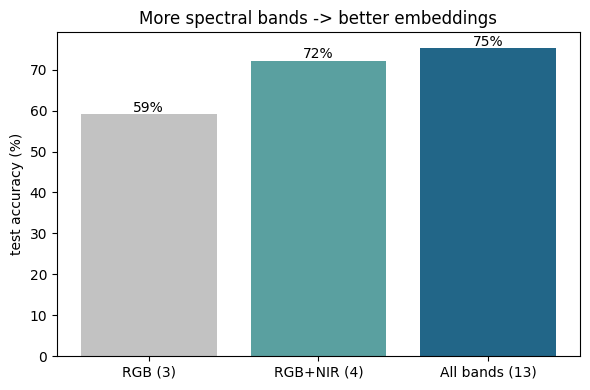

In [6]:
band_sets = {
    "RGB (3)":        [band_names.index(b) for b in ["B04", "B03", "B02"]],
    "RGB+NIR (4)":    [band_names.index(b) for b in ["B04", "B03", "B02", "B08"]],
    "All bands (13)": list(range(13)),
}
band_acc = {}
for name, idx in band_sets.items():
    _, _, a, _ = run_probe(X[..., idx])
    band_acc[name] = a
    print(f"{name:16s} -> {a:.1%}")

plt.figure(figsize=(6, 4))
plt.bar(band_acc.keys(), [v*100 for v in band_acc.values()], color=["#c2c2c2", "#5aa0a0", "#226688"])
plt.ylabel("test accuracy (%)"); plt.title("More spectral bands -> better embeddings")
for i, v in enumerate(band_acc.values()):
    plt.text(i, v*100 + 0.5, f"{v:.0%}", ha="center")
plt.tight_layout(); plt.show()

**Takeaway:** adding the **near-infrared** band gives a big jump — vegetation, water and soil look
very different in NIR even when they look similar in RGB. More spectral bands ⇒ richer embeddings.
This is exactly why purpose-built Earth embeddings ingest *many* sensors.

## 5 · Experiment 2 — how much spatial resolution do we need?

Now we hold the bands fixed (all 13) and shrink the images to 16×16, 32×32, 64×64 pixels before
embedding.

16x16 -> 74.7%


32x32 -> 73.8%


64x64 -> 75.6%


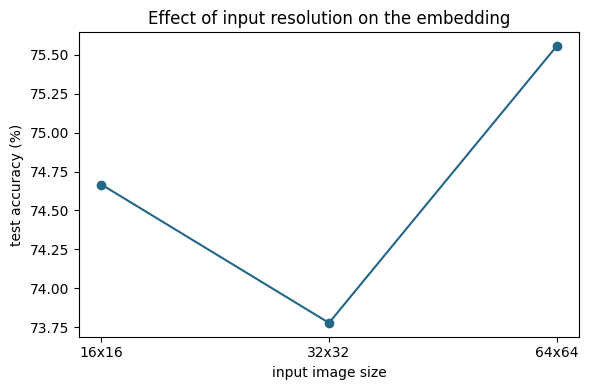

In [7]:
def resize(imgs, s):
    t = torch.from_numpy(imgs.transpose(0, 3, 1, 2).astype(np.float32))
    return F.interpolate(t, size=(s, s), mode="area").numpy().transpose(0, 2, 3, 1)

size_acc = {}
for s in [16, 32, 64]:
    _, _, a, _ = run_probe(resize(X, s))
    size_acc[s] = a
    print(f"{s}x{s} -> {a:.1%}")

plt.figure(figsize=(6, 4))
plt.plot([f"{s}x{s}" for s in size_acc], [v*100 for v in size_acc.values()], "o-", color="#226688")
plt.ylabel("test accuracy (%)"); plt.xlabel("input image size")
plt.title("Effect of input resolution on the embedding"); plt.tight_layout(); plt.show()

**Takeaway:** higher resolution helps, but with diminishing returns — even tiny 16×16 thumbnails
already carry a lot of signal for coarse land-cover. The right resolution depends on how fine-grained
your target is (counting buildings needs more detail than mapping forest-vs-water).

## 6 · From *random* to *learned*: a pretrained foundation model

Every filter so far was **random**. Real Earth *foundation models* instead **learn** their filters from
enormous amounts of imagery. Let's swap in **SSL4EO-S12** — a ResNet-18 pre-trained on ~1 million
Sentinel-2 locations with self-supervised learning (MoCo). It never saw a single land-cover *label*; it
just learned what Sentinel-2 imagery looks like.

We load it straight from the Hugging Face Hub — **no account or login needed**, exactly like SatCLIP in
Demo 1 — freeze it, and use its 512-dimensional output as the embedding. Then we reuse the *same* linear
probe on the *same* train/test split, so the only thing that changes is **random filters → learned
features**.

In [8]:
if RUNNING_IN_COLAB:
    !pip install -q timm
import timm
from huggingface_hub import hf_hub_download

# SSL4EO expects the 13 Sentinel-2 bands in this order; map EuroSAT's band order onto it.
SSL4EO_BANDS = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8a", "B9", "B10", "B11", "B12"]
_key   = lambda b: b.lower().lstrip("b").lstrip("0") or "0"      # "B01"/"B1" -> "1", "B8A" -> "8a"
_lut   = {_key(b): i for i, b in enumerate(band_names)}
reorder = [_lut[_key(b)] for b in SSL4EO_BANDS]

# Download the public pretrained weights (no login) and load into a timm ResNet-18 (13-band input).
ckpt = hf_hub_download("torchgeo/resnet18_sentinel2_all_moco", "resnet18_sentinel2_all_moco.pth")
backbone = timm.create_model("resnet18", in_chans=13, num_classes=0)   # num_classes=0 -> pooled features
state = torch.load(ckpt, map_location="cpu")
state = state.get("state_dict", state)
loaded = backbone.load_state_dict(state, strict=False)
assert not loaded.missing_keys, (
    "SSL4EO checkpoint did not populate the backbone (would leave it at random init); "
    f"missing keys: {loaded.missing_keys[:5]}... unexpected: {loaded.unexpected_keys[:5]}"
)
backbone.eval().to(DEVICE)

@torch.no_grad()
def ssl4eo_embed(imgs, batch=64):
    """Frozen SSL4EO backbone -> one 512-d embedding per image (bands reordered, scaled to reflectance)."""
    x = torch.from_numpy(imgs[..., reorder].transpose(0, 3, 1, 2).astype(np.float32) / 10000.0)
    out = [backbone(x[s:s+batch].to(DEVICE)).cpu().numpy() for s in range(0, len(x), batch)]
    return np.concatenate(out)

t = time.time()
Etr, Ete = ssl4eo_embed(X[tr]), ssl4eo_embed(X[te])
sc_ssl = StandardScaler().fit(Etr)
clf_ssl = LogisticRegression(max_iter=1000).fit(sc_ssl.transform(Etr), y[tr])
acc_ssl = (clf_ssl.predict(sc_ssl.transform(Ete)) == y[te]).mean()
print(f"SSL4EO ResNet-18 (512-d) + linear probe -> test accuracy = {acc_ssl:.1%}"
      f"   [{time.time()-t:.1f}s on {DEVICE}]")

SSL4EO ResNet-18 (512-d) + linear probe -> test accuracy = 93.6%   [4.9s on cpu]


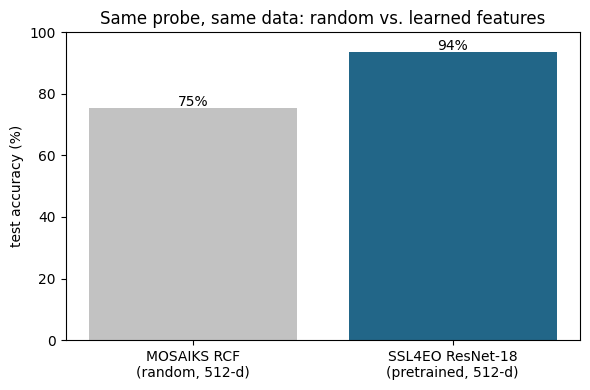

In [9]:
# Same probe, same data: random features vs. a pretrained foundation model.
bars = {f"MOSAIKS RCF\n(random, {2*K}-d)": acc * 100,
        "SSL4EO ResNet-18\n(pretrained, 512-d)": acc_ssl * 100}
plt.figure(figsize=(6, 4))
plt.bar(bars.keys(), bars.values(), color=["#c2c2c2", "#226688"])
for i, v in enumerate(bars.values()):
    plt.text(i, v + 0.6, f"{v:.0f}%", ha="center")
plt.ylabel("test accuracy (%)"); plt.ylim(0, 100)
plt.title("Same probe, same data: random vs. learned features")
plt.tight_layout(); plt.show()

**Takeaway:** with the *same* linear probe and data, the pretrained foundation model clearly beats random
features — its filters encode patterns distilled from a million Sentinel-2 scenes. That is the whole
promise of Earth foundation models: **learn once on unlabelled imagery, then reuse the embeddings
everywhere** with a cheap probe. Random features remain a great training-free baseline; learned features
are the next step up — and everything downstream (the probe, the maps, the similarity search) stays identical.

## 7 · "Find places like this": a similarity map

Embeddings make **search** easy: similar places get similar vectors. We embed a grid of 256 Sentinel-2
patches, pick one as a *query*, and colour every patch by its **cosine similarity** to the query.
Patches that look like the query light up — no labels, no training.

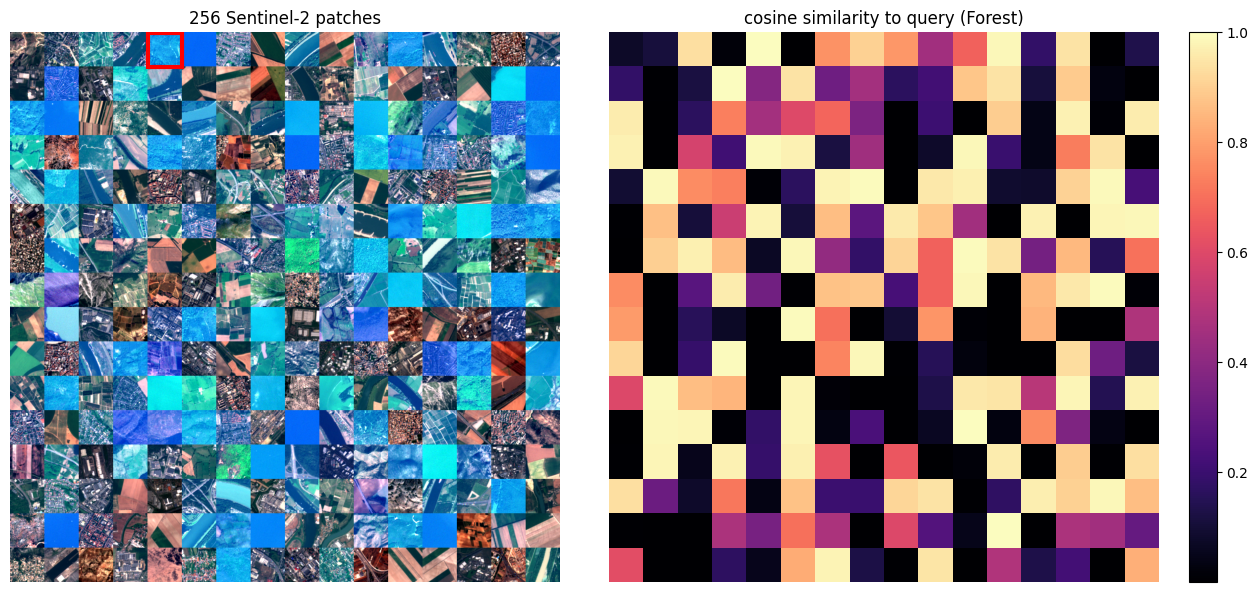

In [10]:
grid = np.load(fetch("eurosat_similarity_grid.npz"), allow_pickle=True)
g_imgs, g_labels = grid["images"], grid["labels"]
gh, gw = int(grid["grid_h"]), int(grid["grid_w"])

g_std, = standardize(g_imgs)
G = rcf_features(g_std, sample_patches(g_std, 256, seed=0))
G /= (np.linalg.norm(G, axis=1, keepdims=True) + 1e-9)   # unit vectors -> dot product = cosine sim

q = int(np.where(g_labels == class_names.index("Forest"))[0][0])   # query: a forest patch
sim = G @ G[q]

montage = np.zeros((gh*64, gw*64, 3))
for i in range(gh*gw):
    r, c = divmod(i, gw)
    montage[r*64:(r+1)*64, c*64:(c+1)*64] = to_rgb(g_imgs[i])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(montage); axes[0].axis("off"); axes[0].set_title("256 Sentinel-2 patches")
qr, qc = divmod(q, gw)
axes[0].add_patch(plt.Rectangle((qc*64, qr*64), 64, 64, ec="red", fc="none", lw=3))
hm = axes[1].imshow(sim.reshape(gh, gw), cmap="magma")
axes[1].axis("off"); axes[1].set_title(f"cosine similarity to query ({class_names[g_labels[q]]})")
plt.colorbar(hm, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

## Wrap-up

* You built a real image **embedding from scratch** with MOSAIKS — **no training required** — and a
  simple **linear probe** on top already classifies land cover well.
* **Design choices are levers:** more **spectral bands** (especially NIR) and more **spatial
  resolution** both improve the embedding. The number of random filters `K` is another knob to try.
* Swapping the random filters for a **pretrained foundation model** (SSL4EO-S12), loaded straight from
  the Hub with no login, kept the exact same probe but gave a clear accuracy bump — a preview of the
  lecture's Part 2 on learned Earth models.
* The same "similar vectors ⇒ similar places" property powers **global similarity search** — the idea
  behind tools like LGND's *Discover*.

The leap from here is scale: production Earth foundation models learn those filters from *planet-sized*
image archives across many sensors — same recipe, far stronger features.

**Resources:** MOSAIKS ([Rolf et al., 2021](https://www.nature.com/articles/s41467-021-24638-z)) ·
[TorchGeo](https://github.com/microsoft/torchgeo) · the tutorial's *Taxonomy of Embeddings*.